<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Giovanni Alejandri Espinosa \\[6pt]
\textbf{Fecha de realización:} & 25/02/2026
\end{array}

</center>

#Parte 2: Convolución

Dada la imagen I = [[1,2,0],[0,1,3],[2,1,0]]

Y el kernel K = [[1,0],[-1,1]]

Aplicar convolución 2D sin padding y stride 1.

Preguntas:

- ¿Qué cambia si se agrega padding?
- ¿Cómo impacta el tamaño del kernel en el costo computacional?


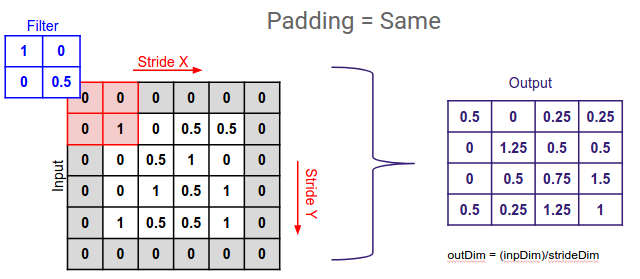

In [ ]:
import numpy as np

# Definimos la imagen I y el kernel K
I = np.array([[1, 2, 0],
              [0, 1, 3],
              [2, 1, 0]])

K = np.array([[1, 0],
              [-1, 1]])

def convolution2d(image, kernel):
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    # Sin padding y stride 1, el tamaño de salida es (N - K + 1)
    out_h = img_h - ker_h + 1
    out_w = img_w - ker_w + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            # Extraemos la región de interés (ventana)
            region = image[i:i+ker_h, j:j+ker_w]
            # Multiplicación elemento a elemento y suma
            output[i, j] = np.sum(region * kernel)

    return output

resultado = convolution2d(I, K)
print("Resultado de la convolución:")
print(resultado)

Resultado de la convolución:
[[ 2.  4.]
 [-1.  0.]]


**¿Qué cambia si se agrega padding?**

El padding (relleno de ceros en los bordes) tiene dos efectos principales:

Mantiene el tamaño: Sin padding, la imagen se encoge en cada capa de convolución. Con el padding adecuado, la salida tiene las mismas dimensiones que la entrada ($3 \times 3$ en tu caso).

Información de los bordes: Sin padding, los píxeles de las esquinas solo se procesan una vez, mientras que los centrales participan en múltiples ventanas. El padding permite que la red "aproveche" mejor la información de los bordes.

**¿Cómo impacta el tamaño del kernel en el costo computacional?**

El impacto es cuadrático.Si tienes un kernel de $k \times k$, por cada píxel de salida realizas $k^2$ multiplicaciones y sumas.

Si duplicas el tamaño del kernel (de $3 \times 3$ a $6 \times 6$), el costo computacional no se duplica, sino que se cuadruplica (pasas de 9 a 36 operaciones por paso).

En modelos grandes, esto puede ralentizar significativamente el entrenamiento, por lo que a menudo se prefieren varios kernels pequeños (como $3 \times 3$) apilados en lugar de uno muy grande.

**Cálculo Manual (para verificar)**

Si quieres comprobar el código, el resultado debería ser:

Posición (0,0): $(1 \times 1) + (2 \times 0) + (0 \times -1) + (1 \times 1) = 2$

Posición (0,1): $(2 \times 1) + (0 \times 0) + (1 \times -1) + (3 \times 1) = 4$

Posición (1,0): $(0 \times 1) + (1 \times 0) + (2 \times -1) + (1 \times 1) = -1$

Posición (1,1): $(1 \times 1) + (3 \times 0) + (1 \times -1) + (0 \times 1) = 0$


Resultado Final:$$\begin{bmatrix} 2 & 4 \\ -1 & 0 \end{bmatrix}$$

# **Ejercicio Adicional: Multiplicación de matrices de tamaño nxn**

Crear una función que reciba el tamaño de la matriz n y muestre el resultado de la multiplicación. Para eso se recomienda crear matrices cuadradas de tamaño 10×10, 100×100, 1000×1000 y 10000 x10000, o hasta donde el poder de su computadora lo soporte. Llenarlas con numero aleatorios del 0 al 99 y que sirva como base para implementar una función de multiplicación de matrices. Ejecutar la multiplicación y mostrar resultados (parcialmente para tamaños grandes) del tamaño que se indique.


In [ ]:
import numpy as np
import time

# FUNCIÓN DE CONVOLUCIÓN 2D
def convolution2d(image, kernel):
    """
    Realiza la convolución 2D entre una imagen y un kernel.

    Parámetros
    ----------
    image : numpy.array
        Matriz que representa la imagen de entrada.

    kernel : numpy.array
        Matriz que representa el filtro o kernel.

    Retorna
    -------
    output : numpy.array
        Matriz resultante después de aplicar la convolución.

    Complejidad
    -----------
    Tiempo: O(n * m * k * l)
    Espacio: O(n * m)
    """

    # Dimensiones de la imagen
    img_h, img_w = image.shape

    # Dimensiones del kernel
    ker_h, ker_w = kernel.shape

    # Cálculo del tamaño de salida (sin padding, stride = 1)
    out_h = img_h - ker_h + 1
    out_w = img_w - ker_w + 1

    # Inicialización de la matriz de salida
    output = np.zeros((out_h, out_w))

    # Recorrido de la imagen
    for i in range(out_h):
        for j in range(out_w):

            # Región de interés
            region = image[i:i+ker_h, j:j+ker_w]

            # Multiplicación elemento a elemento y suma
            output[i, j] = np.sum(region * kernel)

    return output

# FUNCIÓN DE MULTIPLICACIÓN DE MATRICES (implementación clásica)
def matrix_multiplication(A, B):
    """
    Multiplicación clásica de matrices cuadradas.

    Parámetros
    ----------
    A : numpy.array
        Primera matriz.

    B : numpy.array
        Segunda matriz.

    Retorna
    -------
    C : numpy.array
        Matriz resultado.

    Complejidad
    ----------
    Tiempo: O(n^3)
    Espacio: O(n^2)
    """

    n = len(A)

    # Matriz resultado
    C = np.zeros((n, n))

    # Triple ciclo clásico
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]

    return C

# FUNCIÓN PARA MEDIR TIEMPO DE EJECUCIÓN
def test_matrix_multiplication(n):
    """
    Genera dos matrices aleatorias nxn y mide el tiempo de
    ejecución de la multiplicación.

    Parámetros
    ----------
    n : int
        Tamaño de las matrices.
    """

    print(f"\nProbando multiplicación para matrices {n}x{n}")

    # Generar matrices aleatorias
    A = np.random.randint(0, 99, (n, n))
    B = np.random.randint(0, 99, (n, n))

    # Medición de tiempo
    start = time.time()

    C = matrix_multiplication(A, B)

    end = time.time()

    print("Tiempo de ejecución:", end - start, "segundos")

    # Mostrar solo una parte del resultado si es grande
    print("Resultado parcial:")
    print(C[:5, :5])

# EJEMPLO DE CONVOLUCIÓN
I = np.array([[1, 2, 0],
              [0, 1, 3],
              [2, 1, 0]])

K = np.array([[1, 0],
              [-1, 1]])

resultado = convolution2d(I, K)

print("Resultado de la convolución:")
print(resultado)

# PRUEBAS DE MULTIPLICACIÓN DE MATRICES
sizes = [10, 100, 1000, 10000]

for n in sizes:
    test_matrix_multiplication(n)

Resultado de la convolución:
[[ 2.  4.]
 [-1.  0.]]

Probando multiplicación para matrices 10x10
Tiempo de ejecución: 0.001077413558959961 segundos
Resultado parcial:
[[23468. 22454. 18573. 18736. 27923.]
 [22659. 22859. 19530. 21090. 24713.]
 [22450. 27831. 20317. 30322. 18506.]
 [18650. 27461. 21429. 24269. 19310.]
 [13311. 14342. 13296. 15749. 19211.]]

Probando multiplicación para matrices 100x100
Tiempo de ejecución: 1.0818438529968262 segundos
Resultado parcial:
[[262281. 229921. 265109. 276015. 274753.]
 [245745. 228459. 237839. 244299. 258627.]
 [244645. 216285. 249999. 251444. 254574.]
 [270619. 247408. 264579. 258016. 263683.]
 [266658. 249630. 276913. 274529. 266877.]]

Probando multiplicación para matrices 1000x1000
Tiempo de ejecución: 1244.1447410583496 segundos
Resultado parcial:
[[2332290. 2318138. 2406344. 2377098. 2374480.]
 [2308014. 2329757. 2429112. 2345147. 2341215.]
 [2356033. 2404413. 2429588. 2416709. 2468907.]
 [2256601. 2289194. 2326172. 2279801. 2322815.]
 [

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>